In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
from feature_engine.selection import (
    DropDuplicateFeatures,
    DropConstantFeatures,
    SmartCorrelatedSelection
)
from feature_engine.imputation import MeanMedianImputer

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import ExtraTreesClassifier

In [ ]:
df_train = pd.read_csv('/Users/pranshugupta/projects/Jak2Biotech/Datasets/jak2train.csv')
df_test = pd.read_csv('/Users/pranshugupta/projects/Jak2Biotech/Datasets/jak2test.csv')

In [20]:
df_train.dropna(axis=1, thresh= 0.3*len(df_train), inplace=True)

In [24]:
pipe = Pipeline([
    ('fillNa', MeanMedianImputer(imputation_method = 'median')), # imputes medain in na values
    ('constant', DropConstantFeatures(tol=0.98)), # drops constant and quazi constant features
    ('duplicated', DropDuplicateFeatures()), # drop the exact same features
    ('correlation', SmartCorrelatedSelection( # drops correlated
        threshold=0.8,
        selection_method="model_performance",
        estimator=ExtraTreesClassifier()
    ))
])

In [25]:
exp_df = pipe.fit(df_train.drop(['cls'], axis = 1), df_train['cls'])

In [26]:
exp_df

Pipeline(steps=[('fillNa', MeanMedianImputer()),
                ('constant', DropConstantFeatures(tol=0.98)),
                ('duplicated', DropDuplicateFeatures()),
                ('correlation',
                 SmartCorrelatedSelection(estimator=ExtraTreesClassifier(),
                                          selection_method='model_performance'))])

In [29]:
exp_df_train = pipe.transform(df_train.drop(['cls'], axis = 1))

In [30]:
exp_df_train.shape

(9440, 425)

In [31]:
df_test = df_test[df_train.columns]

In [36]:
exp_df_test = pipe.transform(df_test.drop(['cls'], axis = 1))

In [37]:
exp_df_test.shape

(2360, 425)

In [38]:
y_train = df_train['cls']
y_test = df_test['cls']

In [41]:
exp_df_train['cls'] = y_train
exp_df_test['cls'] = y_test

In [42]:
import umap

In [53]:
reducer = umap.UMAP(n_neighbors=15, n_components=2, min_dist=0.1, metric='euclidean')
embedding = reducer.fit_transform(exp_df_train.drop(['cls', 'name'], axis = 1))
embedding_df = pd.DataFrame(data=embedding, columns=['UMAP_1', 'UMAP_2'])
embedding_df['target'] = exp_df_train['cls']

/Users/tanmaysharma/projects/Jak2Biotech/.venv/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:274: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


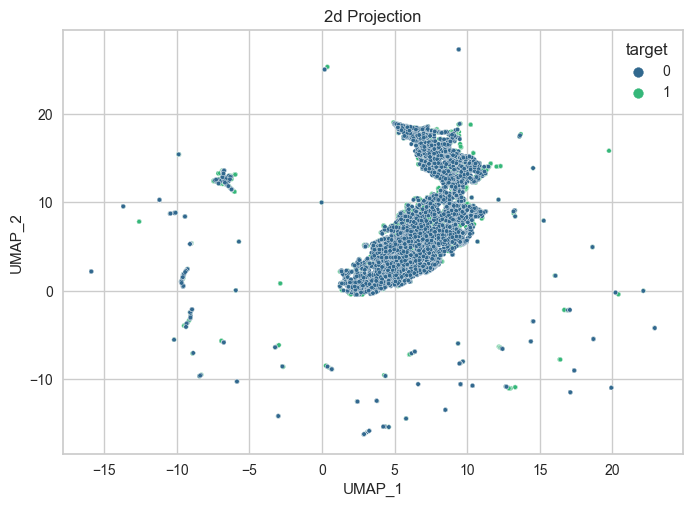

In [54]:
import seaborn as sns

sns.scatterplot(data=embedding_df, x='UMAP_1', y='UMAP_2', hue='target', palette='viridis', legend='full', s=10)
plt.title("2d Projection")
plt.show()

In [62]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

temp_X_train, temp_X_test, temp_y_train, temp_y_test = train_test_split(
    embedding_df_3d.drop(['target'], axis = 1), 
    embedding_df_3d['target'], 
    stratify = embedding_df['target'],
    random_state = 42,
    shuffle = True,
    test_size = 0.25
)

xgb = XGBClassifier()
xgb_model = xgb.fit(temp_X_train, temp_y_train)
xgb_predict = xgb_model.predict(temp_X_test)
accuracy_score(temp_y_test, xgb_predict)

0.6593220338983051

In [46]:
from mpl_toolkits.mplot3d import Axes3D

In [55]:
reducer_3d = umap.UMAP(n_neighbors=15, n_components=3, min_dist=0.1, metric='euclidean')  
embedding_3d = reducer_3d.fit_transform(exp_df_train.drop(['cls', 'name'], axis = 1))
embedding_df_3d = pd.DataFrame(data=embedding_3d, columns=['UMAP_1', 'UMAP_2', 'UMAP_3'])
embedding_df_3d['target'] = exp_df_train['cls']

/Users/tanmaysharma/projects/Jak2Biotech/.venv/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:274: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


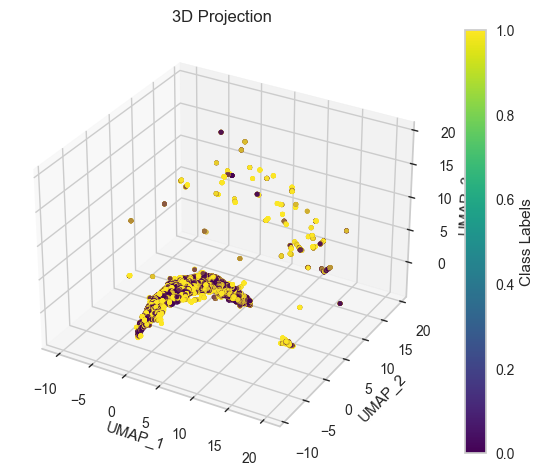

In [56]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(embedding_df_3d['UMAP_1'], embedding_df_3d['UMAP_2'], embedding_df_3d['UMAP_3'], c=embedding_df_3d['target'], cmap='viridis', s=10)
ax.set_title("3D Projection")
ax.set_xlabel("UMAP_1")
ax.set_ylabel("UMAP_2")
ax.set_zlabel("UMAP_3")
colorbar = plt.colorbar(scatter)
colorbar.set_label('Class Labels')
plt.show()

In [39]:
from pycaret.classification import *

In [65]:
exp = setup(
    data = exp_df_train,
    target = 'cls',
    index = False,
    test_data = exp_df_test,
    text_features = ['name'],
    text_features_method = 'tf-idf',
    remove_outliers = 'ee',
    normalize = True,
    normalize_method = 'zscore',
    n_jobs = -1
)

/Users/tanmaysharma/projects/Jak2Biotech/.venv/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/Users/tanmaysharma/projects/Jak2Biotech/.venv/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


,Description,Value
0,Session id,3598
1,Target,cls
2,Target type,Binary
3,Original data shape,"(11800, 426)"
4,Transformed data shape,"(11328, 1885)"
5,Transformed train set shape,"(8968, 1885)"
6,Transformed test set shape,"(2360, 1885)"
7,Numeric features,424
8,Text features,1
9,Preprocess,True


In [68]:
best_models = compare_models(
    sort = 'Accuracy',
    n_select = 5
)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
xgboost,Extreme Gradient Boosting,0.8833,0.9393,0.8771,0.8981,0.8835,0.7665,0.7739,7.7470
lightgbm,Light Gradient Boosting Machine,0.8827,0.9441,0.8746,0.8975,0.8820,0.7655,0.7723,1.4410
et,Extra Trees Classifier,0.8800,0.9109,0.8398,0.9257,0.8751,0.7600,0.7716,1.3650
catboost,CatBoost Classifier,0.8787,0.9422,0.8669,0.8935,0.8768,0.7574,0.7629,10.6520
rf,Random Forest Classifier,0.8760,0.9322,0.8623,0.8961,0.8749,0.7519,0.7593,1.7050
ridge,Ridge Classifier,0.8429,0.0000,0.8343,0.8543,0.8404,0.6858,0.6916,1.1870
lr,Logistic Regression,0.8410,0.9031,0.8479,0.8416,0.8412,0.6820,0.6878,2.2920
lda,Linear Discriminant Analysis,0.8398,0.9030,0.8294,0.8522,0.8368,0.6797,0.6854,2.4400
gbc,Gradient Boosting Classifier,0.8380,0.9162,0.8127,0.8578,0.8299,0.6761,0.6821,8.4780
svm,SVM - Linear Kernel,0.8158,0.0000,0.8182,0.8183,0.8151,0.6316,0.6359,1.5280


In [69]:
nb = create_model('nb')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5667,0.5684,0.9788,0.5366,0.6932,0.1335,0.2357
1,0.5911,0.5924,0.9597,0.5524,0.7012,0.1822,0.2697
2,0.6081,0.6079,0.9831,0.5617,0.7149,0.2161,0.3267
3,0.5763,0.5762,0.9576,0.5433,0.6933,0.1525,0.2359
4,0.5922,0.5933,0.9597,0.5531,0.7018,0.1843,0.2719
5,0.5996,0.6006,0.9640,0.5576,0.7065,0.1992,0.2909
6,0.6186,0.6208,1.0000,0.5673,0.7239,0.2373,0.3669
7,0.6123,0.6115,0.9386,0.5679,0.7077,0.2246,0.2964
8,0.6028,0.6027,0.9661,0.5595,0.7086,0.2055,0.2992


In [70]:
et = create_model('et')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7553,0.7390,0.9343,0.6880,0.7925,0.5106,0.5468
1,0.9047,0.8994,0.8559,0.9484,0.8998,0.8093,0.8132
2,0.9237,0.9144,0.8983,0.9464,0.9217,0.8475,0.8486
3,0.8941,0.8985,0.8199,0.9627,0.8856,0.7881,0.7969
4,0.8708,0.9114,0.7775,0.9557,0.8575,0.7415,0.7548
5,0.8400,0.9272,0.7309,0.9350,0.8205,0.6801,0.6969
6,0.9555,0.9938,0.9661,0.9461,0.9560,0.9110,0.9112
7,0.8294,0.8940,0.6907,0.9560,0.8020,0.6589,0.6858
8,0.8898,0.9526,0.8199,0.9532,0.8815,0.7797,0.7874


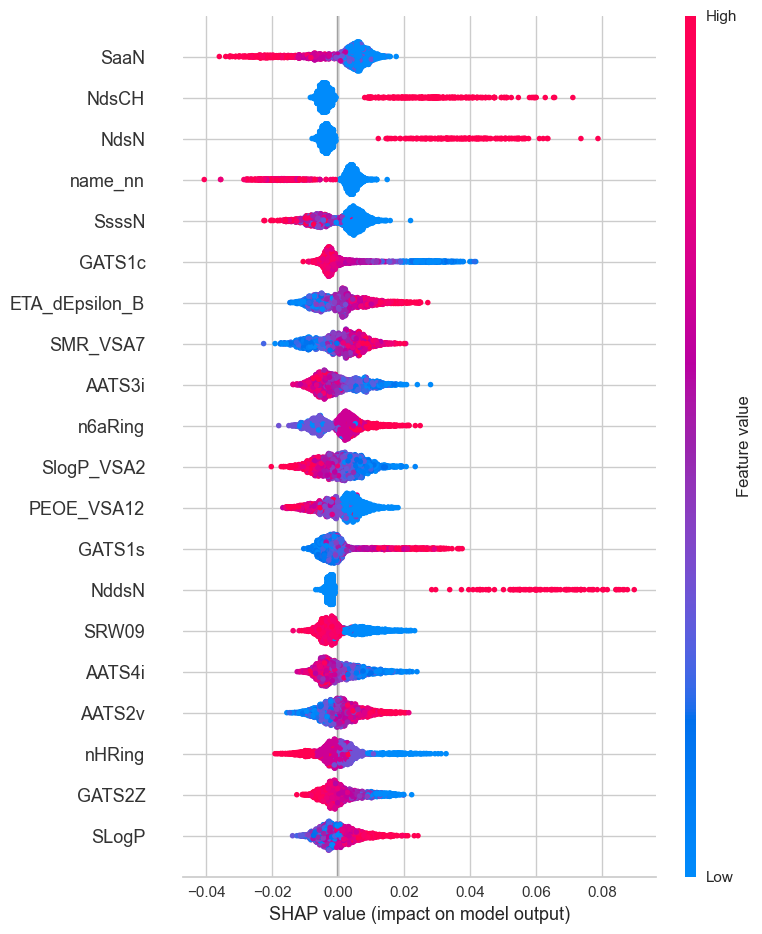

In [73]:
interpret_model(et)

In [71]:
lightgbm = create_model('lightgbm')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7691,0.8584,0.9407,0.7003,0.8029,0.5381,0.5729
1,0.8792,0.9421,0.8496,0.9032,0.8755,0.7585,0.7598
2,0.9121,0.9702,0.9174,0.9078,0.9125,0.8242,0.8242
3,0.9015,0.9579,0.8665,0.9317,0.8979,0.8030,0.8049
4,0.8835,0.9504,0.8326,0.9269,0.8772,0.7669,0.7709
5,0.8909,0.9595,0.8750,0.9037,0.8891,0.7818,0.7822
6,0.9396,0.9845,0.9682,0.9158,0.9413,0.8792,0.8807
7,0.8263,0.8917,0.7055,0.9302,0.8024,0.6525,0.6725
8,0.8919,0.9467,0.8432,0.9343,0.8864,0.7839,0.7876


LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


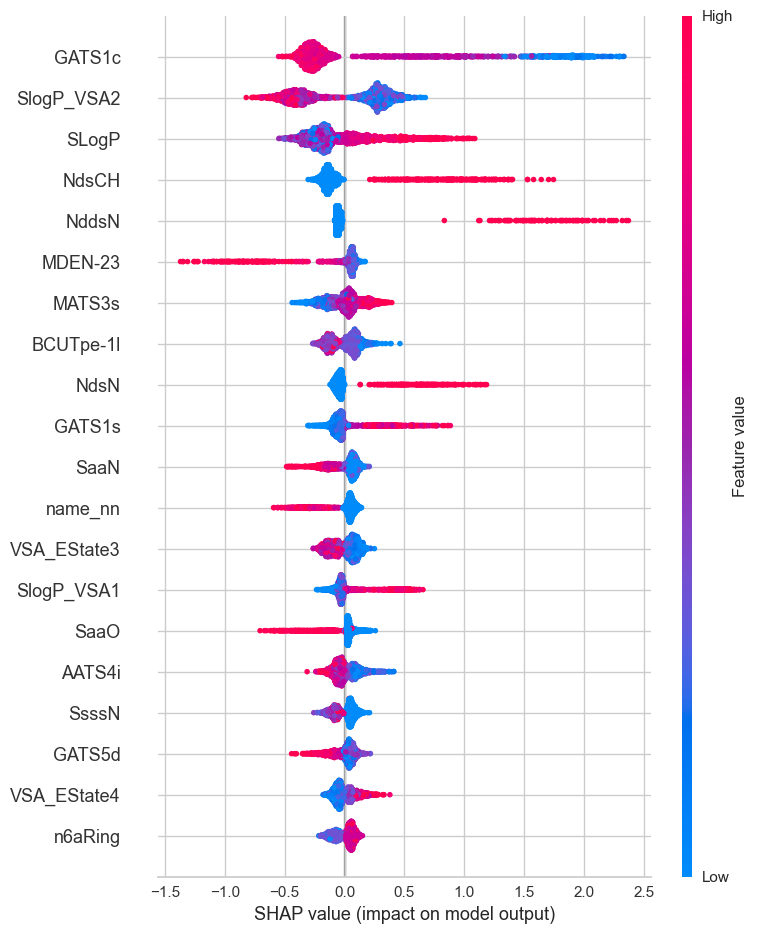

In [74]:
interpret_model(lightgbm)

In [72]:
xgboost = create_model('xgboost')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7564,0.8495,0.9555,0.6833,0.7968,0.5127,0.5590
1,0.8919,0.9394,0.8602,0.9186,0.8884,0.7839,0.7855
2,0.9068,0.9607,0.9068,0.9068,0.9068,0.8136,0.8136
3,0.8898,0.9392,0.8496,0.9240,0.8852,0.7797,0.7822
4,0.8909,0.9443,0.8432,0.9321,0.8854,0.7818,0.7854
5,0.8835,0.9479,0.8475,0.9132,0.8791,0.7669,0.7689
6,0.9481,0.9872,0.9725,0.9273,0.9493,0.8962,0.8973
7,0.8379,0.8983,0.7394,0.9208,0.8202,0.6758,0.6894
8,0.9004,0.9487,0.8559,0.9395,0.8958,0.8008,0.8040


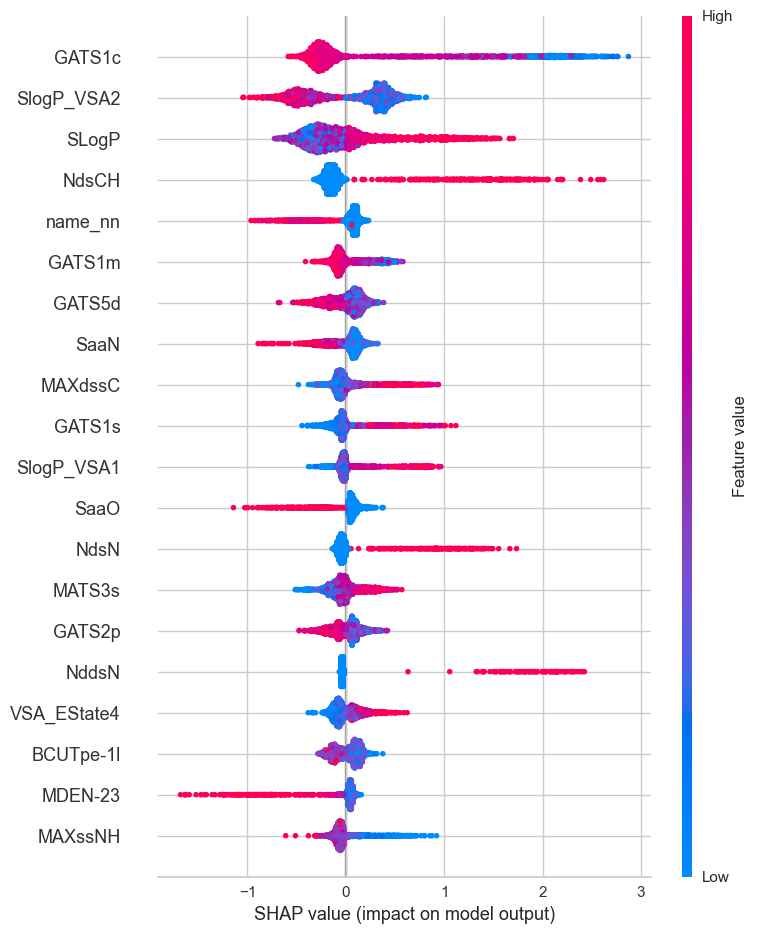

In [75]:
interpret_model(xgboost)

In [77]:
catboost = create_model('catboost')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7924,0.8637,0.9343,0.7277,0.8182,0.5847,0.6098
1,0.8676,0.9359,0.8326,0.8952,0.8628,0.7352,0.7370
2,0.9057,0.9704,0.9110,0.9015,0.9062,0.8114,0.8115
3,0.8898,0.9585,0.8644,0.9107,0.8870,0.7797,0.7807
4,0.8962,0.9539,0.8453,0.9410,0.8906,0.7924,0.7965
5,0.8972,0.9616,0.8750,0.9157,0.8949,0.7945,0.7953
6,0.9269,0.9818,0.9492,0.9087,0.9285,0.8538,0.8547
7,0.8051,0.8794,0.6886,0.8978,0.7794,0.6102,0.6274
8,0.8771,0.9397,0.8305,0.9159,0.8711,0.7542,0.7575


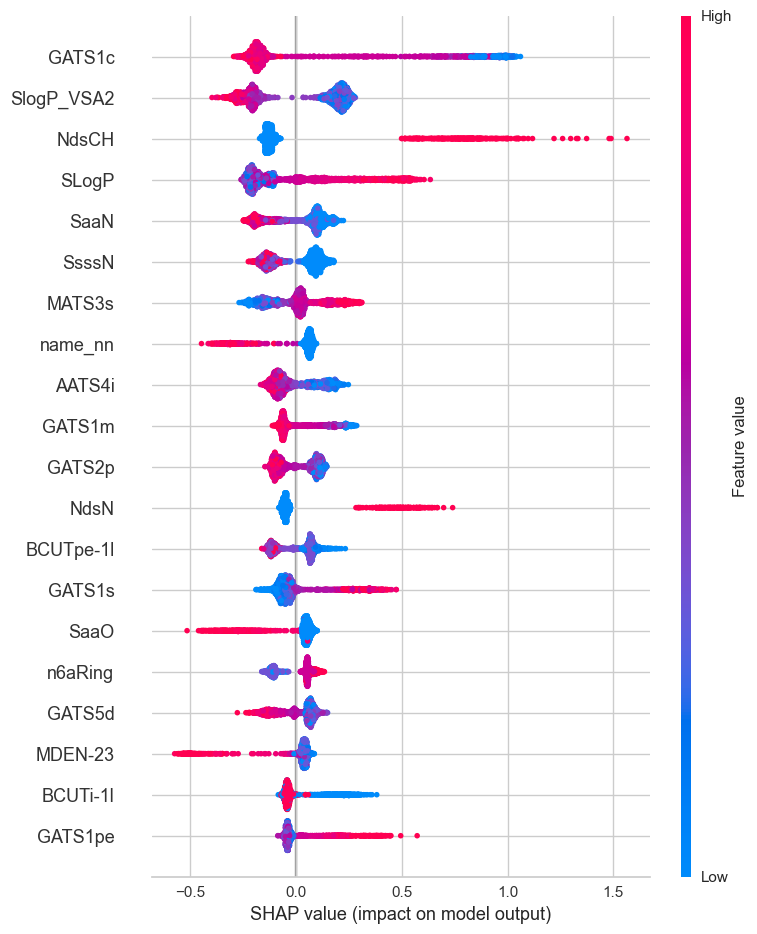

In [79]:
interpret_model(catboost)

In [81]:
tuned_xgboost = tune_model(xgboost, optimize = 'acc')

Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [83]:
tuned_et = tune_model(et, optimize = 'Precision')

Fitting 10 folds for each of 10 candidates, totalling 100 fits


A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [84]:
tuned_nb = tune_model(nb, optimize = 'recall')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5699,0.5702,0.9725,0.5387,0.6934,0.1398,0.2357
1,0.5985,0.5978,0.9492,0.5579,0.7027,0.1970,0.2764
2,0.6165,0.6172,0.9767,0.5677,0.7181,0.2331,0.3360
3,0.5784,0.5784,0.9555,0.5447,0.6938,0.1568,0.2388
4,0.5996,0.6003,0.9576,0.5580,0.7051,0.1992,0.2853
5,0.6049,0.6057,0.9534,0.5618,0.7070,0.2097,0.2925
6,0.6292,0.6292,1.0000,0.5742,0.7295,0.2585,0.3853
7,0.6102,0.6114,0.9301,0.5672,0.7047,0.2203,0.2867
8,0.6070,0.6068,0.9661,0.5623,0.7108,0.2140,0.3075


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [85]:
tuned_lgbm = tune_model(lightgbm, optimize = 'AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7722,0.8581,0.8983,0.7174,0.7977,0.5445,0.5627
1,0.8443,0.9269,0.7903,0.8860,0.8354,0.6886,0.6926
2,0.9100,0.9700,0.9216,0.9006,0.9110,0.8199,0.8201
3,0.9004,0.9619,0.8771,0.9200,0.8980,0.8008,0.8017
4,0.8771,0.9518,0.8347,0.9120,0.8717,0.7542,0.7570
5,0.8792,0.9554,0.8708,0.8858,0.8782,0.7585,0.7586
6,0.9280,0.9800,0.9534,0.9073,0.9298,0.8559,0.8570
7,0.7744,0.8667,0.6356,0.8798,0.7380,0.5487,0.5712
8,0.8729,0.9342,0.8284,0.9093,0.8670,0.7458,0.7487


Fitting 10 folds for each of 10 candidates, totalling 100 fits
[LightGBM] [Warning] bagging_freq is set=2, subsample_freq=0 will be ignored. Current value: bagging_freq=2
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=1.0, subsample=1.0 will be ignored. Current value: bagging_fraction=1.0
[LightGBM] [Warning] bagging_freq is set=2, subsample_freq=0 will be ignored. Current value: bagging_freq=2
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=1.0, subsample=1.0 will be ignored. Current value: bagging_fraction=1.0
[LightGBM] [Warning] bagging_freq is set=2, subsample_freq=0 will be ignored. Current value: bagging_freq=2
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightG

In [86]:
lst_tuned_models = [tuned_lgbm, et, tuned_nb, xgboost]
stack_tuned_models = stack_models(
    estimator_list = lst_tuned_models,
    meta_model = tuned_lgbm, 
    optimize = 'AUC'
)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7564,0.7898,0.9131,0.6952,0.7894,0.5127,0.5399
1,0.9460,0.9882,0.9534,0.9395,0.9464,0.8919,0.8920
2,0.9650,0.9972,0.9831,0.9489,0.9657,0.9301,0.9307
3,0.9481,0.9853,0.9301,0.9648,0.9471,0.8962,0.8968
4,0.9089,0.9732,0.8390,0.9754,0.9021,0.8178,0.8259
5,0.8824,0.9694,0.7945,0.9640,0.8711,0.7648,0.7769
6,0.9513,0.9875,0.9534,0.9494,0.9514,0.9025,0.9026
7,0.8485,0.9227,0.7246,0.9634,0.8271,0.6970,0.7195
8,0.8962,0.9533,0.8284,0.9583,0.8886,0.7924,0.7998


[LightGBM] [Info] Number of positive: 3989, number of negative: 4082
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.177645 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 103745
[LightGBM] [Info] Number of data points in the train set: 8071, number of used features: 663
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.494239 -> initscore=-0.023046
[LightGBM] [Info] Start training from score -0.023046
[LightGBM] [Info] Number of positive: 3977, number of negative: 4095
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.331547 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 103785
[LightGBM] [Info] Number of data points in the train set: 8072, number of used features: 664
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.492691 -> initscore=-0.029239
[LightGBM] [Info] Start training from score -0.029239
[LightGBM] [

[LightGBM] [Info] Number of positive: 4414, number of negative: 4554
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 8968, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.492194 -> initscore=-0.031225
[LightGBM] [Info] Start training from score -0.031225
[LightGBM] [Info] Number of positive: 3531, number of negative: 3643
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000084 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 7174, number of used features: 2
[LightGBM] [Info] Number of positive: 3531, number of negative: 3643
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0

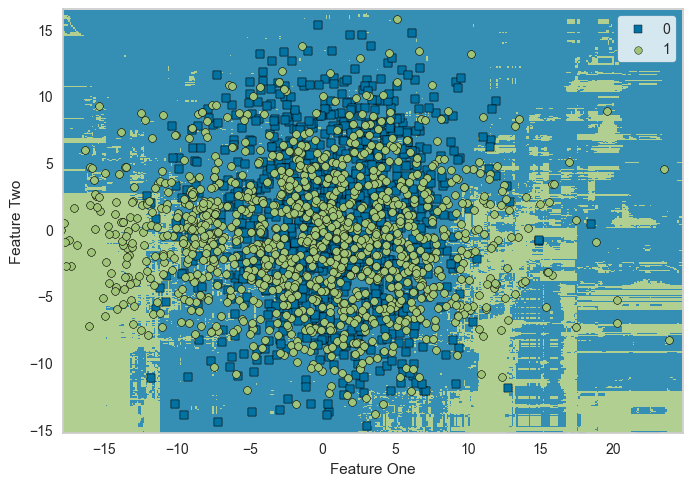

In [87]:
plt.figure(figsize = (8, 8))
plot_model(stack_tuned_models, plot = 'boundary')

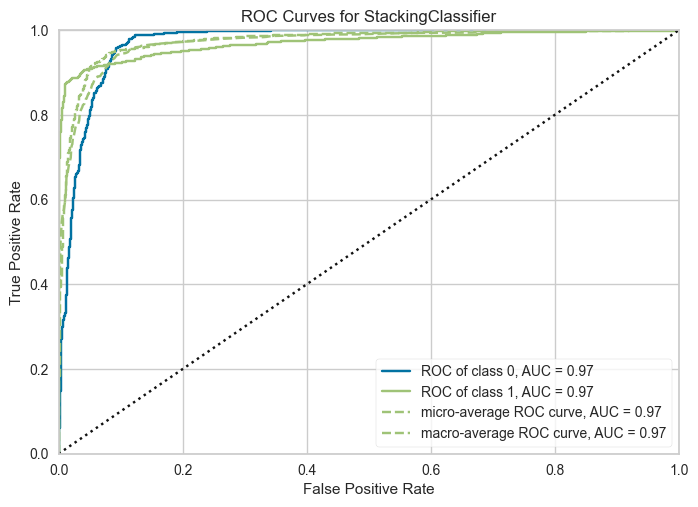

In [88]:
plt.figure(figsize = (8, 8))
plot_model(stack_tuned_models, plot = 'auc')

In [90]:
predict_model(stack_tuned_models)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Stacking Classifier,0.9305,0.9707,0.8958,0.9627,0.9280,0.8610,0.8631


,name,nAcid,nBase,SpMax_A,SpMAD_A,VE1_A,VR1_A,nBr,ATS2m,ATS6m,...,JGI7,JGI8,JGI9,JGI10,SRW09,TSRW10,WPath,cls,prediction_label,prediction_score
9440,CC1=CC(=C(C(=C1C)S(=O)(=O)NCCCN2CCOCC2)C)C,0,1.0,2.465332,1.229564,3.652364,768.452637,0,6814.648438,4276.907715,...,0.015239,0.012346,0.011111,0.007231,0.000000,57.292469,1302,1,0,0.9749
9441,CC1=C(N2C=CC=NC2=N1)C3=CSC(=N3)NC4=CC=C(C=C4)N...,0,0.0,2.438862,1.294084,4.086513,247.596832,1,7488.730469,5033.080566,...,0.014799,0.009747,0.006720,0.006224,7.525640,76.968193,2500001643,1,1,0.9901
9442,CC1=[N+](C2=C(N1C)C=C(C=C2)Cl)CC3=CC=CC=C3.[I-],1,1.0,2.438862,1.294084,4.086513,247.596832,0,5442.681641,3958.768311,...,0.013423,0.014577,0.010000,0.012346,7.195187,68.207512,1900000680,1,1,0.9983
9443,C1CC(OC1)CNS(=O)(=O)C2=CC=C(C=C2)C3=CC=C(C=C3)...,0,0.0,2.409595,1.293957,4.871051,355.804138,0,10558.621094,8424.211914,...,0.009292,0.006725,0.011603,0.009004,6.951772,83.161232,3588,1,1,0.9551
9444,CC1=CC=CN2C1=NC(=C2)C3=CC4=CC=CC=C4OC3=O,0,0.0,2.482653,1.331947,4.223250,130.264526,0,5809.644043,3757.420898,...,0.014760,0.010478,0.004923,0.005679,6.861712,69.501961,893,1,0,0.8794
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11795,CC1=NN=C(O1)SCC(=O)NC2=CC3=C(C=C2)OCO3,0,0.0,2.370723,1.301287,3.607111,247.863861,0,6316.258301,3759.669434,...,0.007815,0.008781,0.007604,0.005643,7.247793,68.846703,940,0,0,0.9764
11796,C1CC(CN(C1)S(=O)(=O)C2=CC=CC=C2)C(=O)NC3=CC=C(...,0,0.0,2.432201,1.323149,4.267554,551.324890,0,9136.021484,7033.656250,...,0.013889,0.011329,0.006296,0.003958,0.000000,65.778412,2792,0,0,0.9218
11797,CC1=C(C=C(C=C1)NC(=O)CN2C(=O)C3=CC=CC=C3C(=N2)C)F,0,0.0,2.443993,1.275908,3.878948,329.857819,0,6326.751465,4449.249512,...,0.012626,0.012886,0.009079,0.007972,0.000000,58.703388,1425,0,1,0.5374
11798,CCCC1=NC2=NC=NN2C(=C1)N3CCCC(C3)C(=O)NC4=C(C=C...,0,0.0,2.468043,1.314685,4.425002,434.618866,0,8279.666016,8778.245117,...,0.010915,0.010338,0.007533,0.006604,6.605298,80.516701,2754,0,0,0.9982


In [91]:
tune_stacked_model = tune_model(stack_tuned_models, optimize = 'AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7606,0.8287,0.9131,0.6997,0.7923,0.5212,0.5473
1,0.9470,0.9857,0.9470,0.9470,0.9470,0.8941,0.8941
2,0.9661,0.9941,0.9703,0.9622,0.9662,0.9322,0.9322
3,0.9460,0.9845,0.9216,0.9688,0.9446,0.8919,0.8930
4,0.9057,0.9757,0.8347,0.9728,0.8985,0.8114,0.8197
5,0.8856,0.9652,0.7987,0.9667,0.8747,0.7712,0.7831
6,0.9566,0.9890,0.9534,0.9595,0.9564,0.9131,0.9132
7,0.8422,0.9151,0.7013,0.9764,0.8163,0.6843,0.7132
8,0.9004,0.9550,0.8220,0.9749,0.8920,0.8008,0.8109


Fitting 10 folds for each of 10 candidates, totalling 100 fits
[LightGBM] [Info] Number of positive: 3944, number of negative: 4127
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.309416 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 103717
[LightGBM] [Info] Number of data points in the train set: 8071, number of used features: 661
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.488663 -> initscore=-0.045355
[LightGBM] [Info] Start training from score -0.045355
[LightGBM] [Info] Number of positive: 3979, number of negative: 4093
[LightGBM] [Info] Number of positive: 3974, number of negative: 4097
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.076892 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 103689
[LightGBM] [Info] Number of data points in the train set: 8072, number of used features: 663
[LightGBM] [In

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging

In [92]:
predict_model(tune_stacked_model)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Stacking Classifier,0.9242,0.9685,0.8831,0.9621,0.9209,0.8483,0.8512


[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9


,name,nAcid,nBase,SpMax_A,SpMAD_A,VE1_A,VR1_A,nBr,ATS2m,ATS6m,...,JGI7,JGI8,JGI9,JGI10,SRW09,TSRW10,WPath,cls,prediction_label,prediction_score
9440,CC1=CC(=C(C(=C1C)S(=O)(=O)NCCCN2CCOCC2)C)C,0,1.0,2.465332,1.229564,3.652364,768.452637,0,6814.648438,4276.907715,...,0.015239,0.012346,0.011111,0.007231,0.000000,57.292469,1302,1,0,0.5423
9441,CC1=C(N2C=CC=NC2=N1)C3=CSC(=N3)NC4=CC=C(C=C4)N...,0,0.0,2.438862,1.294084,4.086513,247.596832,1,7488.730469,5033.080566,...,0.014799,0.009747,0.006720,0.006224,7.525640,76.968193,2500001643,1,1,0.5569
9442,CC1=[N+](C2=C(N1C)C=C(C=C2)Cl)CC3=CC=CC=C3.[I-],1,1.0,2.438862,1.294084,4.086513,247.596832,0,5442.681641,3958.768311,...,0.013423,0.014577,0.010000,0.012346,7.195187,68.207512,1900000680,1,1,0.5599
9443,C1CC(OC1)CNS(=O)(=O)C2=CC=C(C=C2)C3=CC=C(C=C3)...,0,0.0,2.409595,1.293957,4.871051,355.804138,0,10558.621094,8424.211914,...,0.009292,0.006725,0.011603,0.009004,6.951772,83.161232,3588,1,1,0.5382
9444,CC1=CC=CN2C1=NC(=C2)C3=CC4=CC=CC=C4OC3=O,0,0.0,2.482653,1.331947,4.223250,130.264526,0,5809.644043,3757.420898,...,0.014760,0.010478,0.004923,0.005679,6.861712,69.501961,893,1,0,0.5468
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11795,CC1=NN=C(O1)SCC(=O)NC2=CC3=C(C=C2)OCO3,0,0.0,2.370723,1.301287,3.607111,247.863861,0,6316.258301,3759.669434,...,0.007815,0.008781,0.007604,0.005643,7.247793,68.846703,940,0,0,0.5663
11796,C1CC(CN(C1)S(=O)(=O)C2=CC=CC=C2)C(=O)NC3=CC=C(...,0,0.0,2.432201,1.323149,4.267554,551.324890,0,9136.021484,7033.656250,...,0.013889,0.011329,0.006296,0.003958,0.000000,65.778412,2792,0,0,0.5632
11797,CC1=C(C=C(C=C1)NC(=O)CN2C(=O)C3=CC=CC=C3C(=N2)C)F,0,0.0,2.443993,1.275908,3.878948,329.857819,0,6326.751465,4449.249512,...,0.012626,0.012886,0.009079,0.007972,0.000000,58.703388,1425,0,0,0.5249
11798,CCCC1=NC2=NC=NN2C(=C1)N3CCCC(C3)C(=O)NC4=C(C=C...,0,0.0,2.468043,1.314685,4.425002,434.618866,0,8279.666016,8778.245117,...,0.010915,0.010338,0.007533,0.006604,6.605298,80.516701,2754,0,0,0.5724


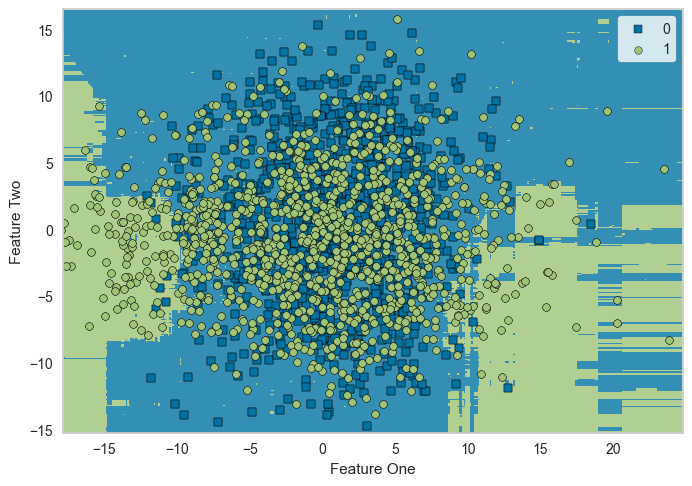

In [93]:
plt.figure(figsize = (8, 8))
plot_model(tune_stacked_model, plot = 'boundary')

In [94]:
blend_soft = blend_models(estimator_list = lst_tuned_models, optimize = 'AUC', method = 'soft')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7542,0.8181,0.9682,0.6780,0.7976,0.5085,0.5626
1,0.8782,0.9257,0.8898,0.8696,0.8796,0.7564,0.7566
2,0.8845,0.9530,0.9110,0.8652,0.8875,0.7691,0.7701
3,0.8729,0.9298,0.8729,0.8729,0.8729,0.7458,0.7458
4,0.8845,0.9329,0.8771,0.8903,0.8837,0.7691,0.7692
5,0.8739,0.9469,0.8792,0.8700,0.8746,0.7479,0.7479
6,0.9195,0.9936,0.9873,0.8694,0.9246,0.8390,0.8468
7,0.8443,0.8959,0.7860,0.8897,0.8346,0.6886,0.6933
8,0.8962,0.9530,0.8941,0.8979,0.8960,0.7924,0.7924


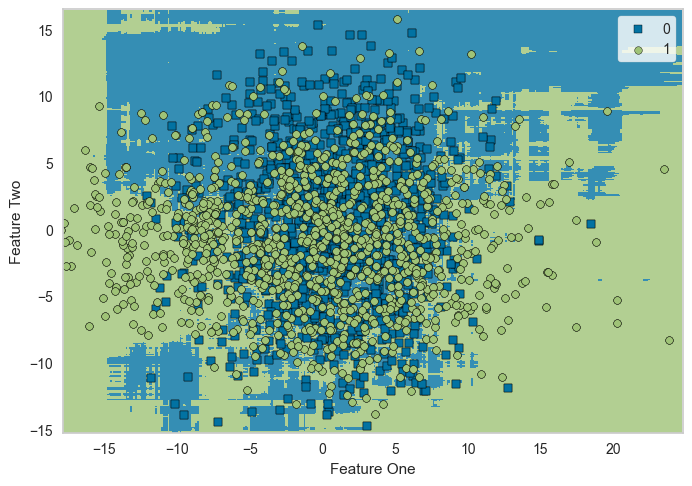

In [95]:
plt.figure(figsize = (8,8))
plot_model(blend_soft, plot = 'boundary')

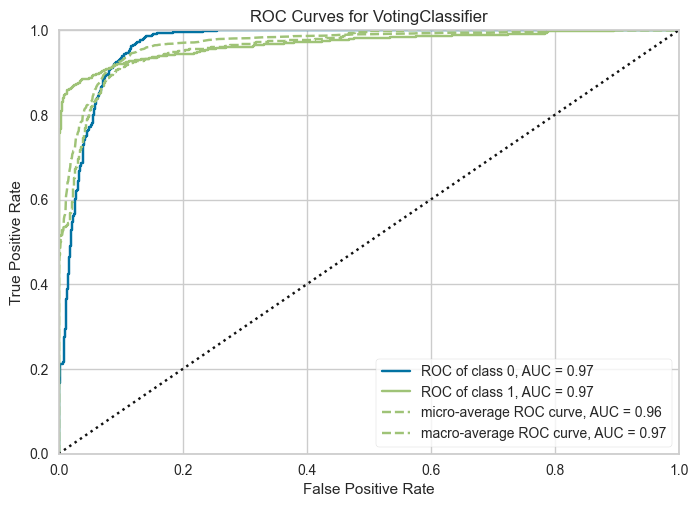

In [97]:
plt.figure(figsize = (8,8))
plot_model(blend_soft, plot = 'auc')

In [98]:
predict_model(blend_soft)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Voting Classifier,0.9059,0.9676,0.9263,0.8901,0.9078,0.8119,0.8125


,name,nAcid,nBase,SpMax_A,SpMAD_A,VE1_A,VR1_A,nBr,ATS2m,ATS6m,...,JGI7,JGI8,JGI9,JGI10,SRW09,TSRW10,WPath,cls,prediction_label,prediction_score
9440,CC1=CC(=C(C(=C1C)S(=O)(=O)NCCCN2CCOCC2)C)C,0,1.0,2.465332,1.229564,3.652364,768.452637,0,6814.648438,4276.907715,...,0.015239,0.012346,0.011111,0.007231,0.000000,57.292469,1302,1,0,0.8105
9441,CC1=C(N2C=CC=NC2=N1)C3=CSC(=N3)NC4=CC=C(C=C4)N...,0,0.0,2.438862,1.294084,4.086513,247.596832,1,7488.730469,5033.080566,...,0.014799,0.009747,0.006720,0.006224,7.525640,76.968193,2500001643,1,1,0.9782
9442,CC1=[N+](C2=C(N1C)C=C(C=C2)Cl)CC3=CC=CC=C3.[I-],1,1.0,2.438862,1.294084,4.086513,247.596832,0,5442.681641,3958.768311,...,0.013423,0.014577,0.010000,0.012346,7.195187,68.207512,1900000680,1,1,0.9992
9443,C1CC(OC1)CNS(=O)(=O)C2=CC=C(C=C2)C3=CC=C(C=C3)...,0,0.0,2.409595,1.293957,4.871051,355.804138,0,10558.621094,8424.211914,...,0.009292,0.006725,0.011603,0.009004,6.951772,83.161232,3588,1,1,0.9000
9444,CC1=CC=CN2C1=NC(=C2)C3=CC4=CC=CC=C4OC3=O,0,0.0,2.482653,1.331947,4.223250,130.264526,0,5809.644043,3757.420898,...,0.014760,0.010478,0.004923,0.005679,6.861712,69.501961,893,1,0,0.5016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11795,CC1=NN=C(O1)SCC(=O)NC2=CC3=C(C=C2)OCO3,0,0.0,2.370723,1.301287,3.607111,247.863861,0,6316.258301,3759.669434,...,0.007815,0.008781,0.007604,0.005643,7.247793,68.846703,940,0,0,0.7087
11796,C1CC(CN(C1)S(=O)(=O)C2=CC=CC=C2)C(=O)NC3=CC=C(...,0,0.0,2.432201,1.323149,4.267554,551.324890,0,9136.021484,7033.656250,...,0.013889,0.011329,0.006296,0.003958,0.000000,65.778412,2792,0,0,0.6458
11797,CC1=C(C=C(C=C1)NC(=O)CN2C(=O)C3=CC=CC=C3C(=N2)C)F,0,0.0,2.443993,1.275908,3.878948,329.857819,0,6326.751465,4449.249512,...,0.012626,0.012886,0.009079,0.007972,0.000000,58.703388,1425,0,1,0.6818
11798,CCCC1=NC2=NC=NN2C(=C1)N3CCCC(C3)C(=O)NC4=C(C=C...,0,0.0,2.468043,1.314685,4.425002,434.618866,0,8279.666016,8778.245117,...,0.010915,0.010338,0.007533,0.006604,6.605298,80.516701,2754,0,0,0.7327


In [104]:
blend_hard = blend_models(
    estimator_list = lst_tuned_models,
    optimize = 'acc',
    method = 'hard'
)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7617,0.0000,0.9470,0.6909,0.7989,0.5233,0.5635
1,0.8930,0.0000,0.8581,0.9226,0.8891,0.7860,0.7879
2,0.9163,0.0000,0.9047,0.9262,0.9153,0.8326,0.8329
3,0.8994,0.0000,0.8496,0.9435,0.8941,0.7987,0.8027
4,0.8888,0.0000,0.8305,0.9400,0.8819,0.7775,0.7829
5,0.8814,0.0000,0.8326,0.9225,0.8753,0.7627,0.7664
6,0.9597,0.0000,0.9767,0.9447,0.9604,0.9195,0.9200
7,0.8326,0.0000,0.7097,0.9410,0.8092,0.6653,0.6863
8,0.8983,0.0000,0.8390,0.9519,0.8919,0.7966,0.8023


Processing:   0%|          | 0/6 [00:00<?, ?it/s]

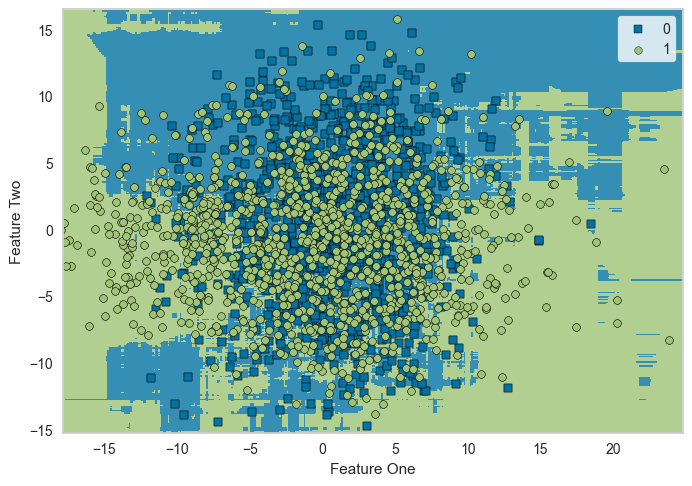

In [105]:
plt.figure(figsize = (8,8))
plot_model(blend_hard, plot = 'boundary')

In [108]:
predict_model(blend_hard)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Voting Classifier,0.9174,0.9174,0.8958,0.9362,0.9155,0.8347,0.8355


,name,nAcid,nBase,SpMax_A,SpMAD_A,VE1_A,VR1_A,nBr,ATS2m,ATS6m,...,JGI6,JGI7,JGI8,JGI9,JGI10,SRW09,TSRW10,WPath,cls,prediction_label
9440,CC1=CC(=C(C(=C1C)S(=O)(=O)NCCCN2CCOCC2)C)C,0,1.0,2.465332,1.229564,3.652364,768.452637,0,6814.648438,4276.907715,...,0.021513,0.015239,0.012346,0.011111,0.007231,0.000000,57.292469,1302,1,0
9441,CC1=C(N2C=CC=NC2=N1)C3=CSC(=N3)NC4=CC=C(C=C4)N...,0,0.0,2.438862,1.294084,4.086513,247.596832,1,7488.730469,5033.080566,...,0.017259,0.014799,0.009747,0.006720,0.006224,7.525640,76.968193,2500001643,1,1
9442,CC1=[N+](C2=C(N1C)C=C(C=C2)Cl)CC3=CC=CC=C3.[I-],1,1.0,2.438862,1.294084,4.086513,247.596832,0,5442.681641,3958.768311,...,0.012336,0.013423,0.014577,0.010000,0.012346,7.195187,68.207512,1900000680,1,1
9443,C1CC(OC1)CNS(=O)(=O)C2=CC=C(C=C2)C3=CC=C(C=C3)...,0,0.0,2.409595,1.293957,4.871051,355.804138,0,10558.621094,8424.211914,...,0.024084,0.009292,0.006725,0.011603,0.009004,6.951772,83.161232,3588,1,1
9444,CC1=CC=CN2C1=NC(=C2)C3=CC4=CC=CC=C4OC3=O,0,0.0,2.482653,1.331947,4.223250,130.264526,0,5809.644043,3757.420898,...,0.014768,0.014760,0.010478,0.004923,0.005679,6.861712,69.501961,893,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11795,CC1=NN=C(O1)SCC(=O)NC2=CC3=C(C=C2)OCO3,0,0.0,2.370723,1.301287,3.607111,247.863861,0,6316.258301,3759.669434,...,0.023580,0.007815,0.008781,0.007604,0.005643,7.247793,68.846703,940,0,0
11796,C1CC(CN(C1)S(=O)(=O)C2=CC=CC=C2)C(=O)NC3=CC=C(...,0,0.0,2.432201,1.323149,4.267554,551.324890,0,9136.021484,7033.656250,...,0.014950,0.013889,0.011329,0.006296,0.003958,0.000000,65.778412,2792,0,0
11797,CC1=C(C=C(C=C1)NC(=O)CN2C(=O)C3=CC=CC=C3C(=N2)C)F,0,0.0,2.443993,1.275908,3.878948,329.857819,0,6326.751465,4449.249512,...,0.020231,0.012626,0.012886,0.009079,0.007972,0.000000,58.703388,1425,0,1
11798,CCCC1=NC2=NC=NN2C(=C1)N3CCCC(C3)C(=O)NC4=C(C=C...,0,0.0,2.468043,1.314685,4.425002,434.618866,0,8279.666016,8778.245117,...,0.010986,0.010915,0.010338,0.007533,0.006604,6.605298,80.516701,2754,0,0


In [109]:
best_model = compare_models([tune_stacked_model, stack_tuned_models, blend_hard, blend_soft])

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
0,Stacking Classifier,0.9057,0.9577,0.8790,0.9393,0.9034,0.8114,0.8201,44.5940
1,Stacking Classifier,0.9048,0.9549,0.8860,0.9308,0.9033,0.8095,0.8174,41.3620
2,Voting Classifier,0.8871,0.0000,0.8684,0.9126,0.8856,0.7742,0.7824,8.7550
3,Voting Classifier,0.8724,0.9326,0.9021,0.8587,0.8770,0.7447,0.7518,8.9390


In [110]:
predict_model(best_model)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Stacking Classifier,0.9242,0.9685,0.8831,0.9621,0.9209,0.8483,0.8512


[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9


,name,nAcid,nBase,SpMax_A,SpMAD_A,VE1_A,VR1_A,nBr,ATS2m,ATS6m,...,JGI7,JGI8,JGI9,JGI10,SRW09,TSRW10,WPath,cls,prediction_label,prediction_score
9440,CC1=CC(=C(C(=C1C)S(=O)(=O)NCCCN2CCOCC2)C)C,0,1.0,2.465332,1.229564,3.652364,768.452637,0,6814.648438,4276.907715,...,0.015239,0.012346,0.011111,0.007231,0.000000,57.292469,1302,1,0,0.5423
9441,CC1=C(N2C=CC=NC2=N1)C3=CSC(=N3)NC4=CC=C(C=C4)N...,0,0.0,2.438862,1.294084,4.086513,247.596832,1,7488.730469,5033.080566,...,0.014799,0.009747,0.006720,0.006224,7.525640,76.968193,2500001643,1,1,0.5569
9442,CC1=[N+](C2=C(N1C)C=C(C=C2)Cl)CC3=CC=CC=C3.[I-],1,1.0,2.438862,1.294084,4.086513,247.596832,0,5442.681641,3958.768311,...,0.013423,0.014577,0.010000,0.012346,7.195187,68.207512,1900000680,1,1,0.5599
9443,C1CC(OC1)CNS(=O)(=O)C2=CC=C(C=C2)C3=CC=C(C=C3)...,0,0.0,2.409595,1.293957,4.871051,355.804138,0,10558.621094,8424.211914,...,0.009292,0.006725,0.011603,0.009004,6.951772,83.161232,3588,1,1,0.5382
9444,CC1=CC=CN2C1=NC(=C2)C3=CC4=CC=CC=C4OC3=O,0,0.0,2.482653,1.331947,4.223250,130.264526,0,5809.644043,3757.420898,...,0.014760,0.010478,0.004923,0.005679,6.861712,69.501961,893,1,0,0.5468
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11795,CC1=NN=C(O1)SCC(=O)NC2=CC3=C(C=C2)OCO3,0,0.0,2.370723,1.301287,3.607111,247.863861,0,6316.258301,3759.669434,...,0.007815,0.008781,0.007604,0.005643,7.247793,68.846703,940,0,0,0.5663
11796,C1CC(CN(C1)S(=O)(=O)C2=CC=CC=C2)C(=O)NC3=CC=C(...,0,0.0,2.432201,1.323149,4.267554,551.324890,0,9136.021484,7033.656250,...,0.013889,0.011329,0.006296,0.003958,0.000000,65.778412,2792,0,0,0.5632
11797,CC1=C(C=C(C=C1)NC(=O)CN2C(=O)C3=CC=CC=C3C(=N2)C)F,0,0.0,2.443993,1.275908,3.878948,329.857819,0,6326.751465,4449.249512,...,0.012626,0.012886,0.009079,0.007972,0.000000,58.703388,1425,0,0,0.5249
11798,CCCC1=NC2=NC=NN2C(=C1)N3CCCC(C3)C(=O)NC4=C(C=C...,0,0.0,2.468043,1.314685,4.425002,434.618866,0,8279.666016,8778.245117,...,0.010915,0.010338,0.007533,0.006604,6.605298,80.516701,2754,0,0,0.5724


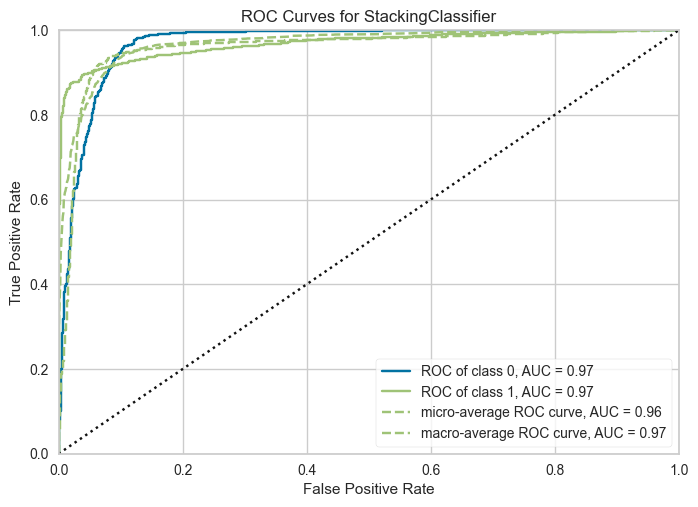

In [111]:
plot_model(best_model, plot = 'auc')

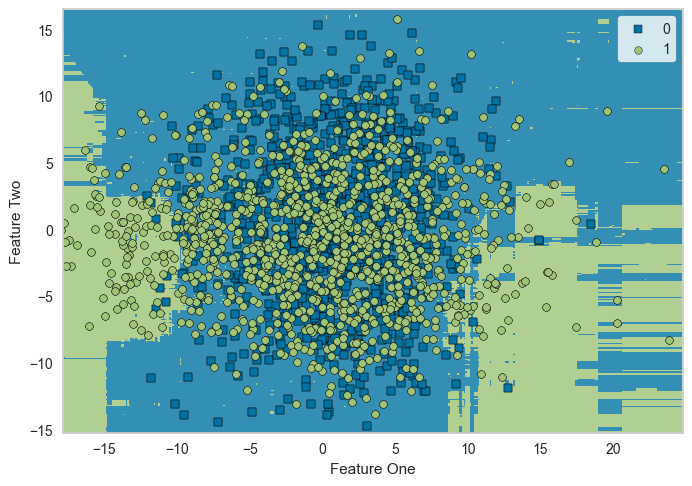

In [112]:
plot_model(best_model, plot = 'boundary')

In [114]:
cali_model = calibrate_model(best_model)

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,01:35:05
Status,. . . . . . . . . . . . . . . . . .,Loading Dependencies
Estimator,. . . . . . . . . . . . . . . . . .,Compiling Library


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7638,0.8728,0.9428,0.6942,0.7996,0.5275,0.5650
1,0.9481,0.9834,0.9597,0.9379,0.9487,0.8962,0.8964
2,0.9555,0.9909,0.9831,0.9317,0.9567,0.9110,0.9124
3,0.9492,0.9852,0.9428,0.9549,0.9488,0.8983,0.8984
4,0.9206,0.9766,0.8792,0.9584,0.9171,0.8411,0.8440
5,0.9047,0.9718,0.8559,0.9484,0.8998,0.8093,0.8132
6,0.9502,0.9906,0.9682,0.9346,0.9511,0.9004,0.9010
7,0.8432,0.9105,0.7288,0.9451,0.8230,0.6864,0.7051
8,0.8994,0.9512,0.8475,0.9456,0.8939,0.7987,0.8031


In [115]:
predict_model(cali_model)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Stacking Classifier,0.9254,0.9666,0.8983,0.9498,0.9233,0.8508,0.8521


[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will b

,name,nAcid,nBase,SpMax_A,SpMAD_A,VE1_A,VR1_A,nBr,ATS2m,ATS6m,...,JGI7,JGI8,JGI9,JGI10,SRW09,TSRW10,WPath,cls,prediction_label,prediction_score
9440,CC1=CC(=C(C(=C1C)S(=O)(=O)NCCCN2CCOCC2)C)C,0,1.0,2.465332,1.229564,3.652364,768.452637,0,6814.648438,4276.907715,...,0.015239,0.012346,0.011111,0.007231,0.000000,57.292469,1302,1,0,0.8340
9441,CC1=C(N2C=CC=NC2=N1)C3=CSC(=N3)NC4=CC=C(C=C4)N...,0,0.0,2.438862,1.294084,4.086513,247.596832,1,7488.730469,5033.080566,...,0.014799,0.009747,0.006720,0.006224,7.525640,76.968193,2500001643,1,1,0.9598
9442,CC1=[N+](C2=C(N1C)C=C(C=C2)Cl)CC3=CC=CC=C3.[I-],1,1.0,2.438862,1.294084,4.086513,247.596832,0,5442.681641,3958.768311,...,0.013423,0.014577,0.010000,0.012346,7.195187,68.207512,1900000680,1,1,0.9727
9443,C1CC(OC1)CNS(=O)(=O)C2=CC=C(C=C2)C3=CC=C(C=C3)...,0,0.0,2.409595,1.293957,4.871051,355.804138,0,10558.621094,8424.211914,...,0.009292,0.006725,0.011603,0.009004,6.951772,83.161232,3588,1,1,0.7553
9444,CC1=CC=CN2C1=NC(=C2)C3=CC4=CC=CC=C4OC3=O,0,0.0,2.482653,1.331947,4.223250,130.264526,0,5809.644043,3757.420898,...,0.014760,0.010478,0.004923,0.005679,6.861712,69.501961,893,1,0,0.8448
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11795,CC1=NN=C(O1)SCC(=O)NC2=CC3=C(C=C2)OCO3,0,0.0,2.370723,1.301287,3.607111,247.863861,0,6316.258301,3759.669434,...,0.007815,0.008781,0.007604,0.005643,7.247793,68.846703,940,0,0,0.9619
11796,C1CC(CN(C1)S(=O)(=O)C2=CC=CC=C2)C(=O)NC3=CC=C(...,0,0.0,2.432201,1.323149,4.267554,551.324890,0,9136.021484,7033.656250,...,0.013889,0.011329,0.006296,0.003958,0.000000,65.778412,2792,0,0,0.9491
11797,CC1=C(C=C(C=C1)NC(=O)CN2C(=O)C3=CC=CC=C3C(=N2)C)F,0,0.0,2.443993,1.275908,3.878948,329.857819,0,6326.751465,4449.249512,...,0.012626,0.012886,0.009079,0.007972,0.000000,58.703388,1425,0,1,0.5794
11798,CCCC1=NC2=NC=NN2C(=C1)N3CCCC(C3)C(=O)NC4=C(C=C...,0,0.0,2.468043,1.314685,4.425002,434.618866,0,8279.666016,8778.245117,...,0.010915,0.010338,0.007533,0.006604,6.605298,80.516701,2754,0,0,0.9720


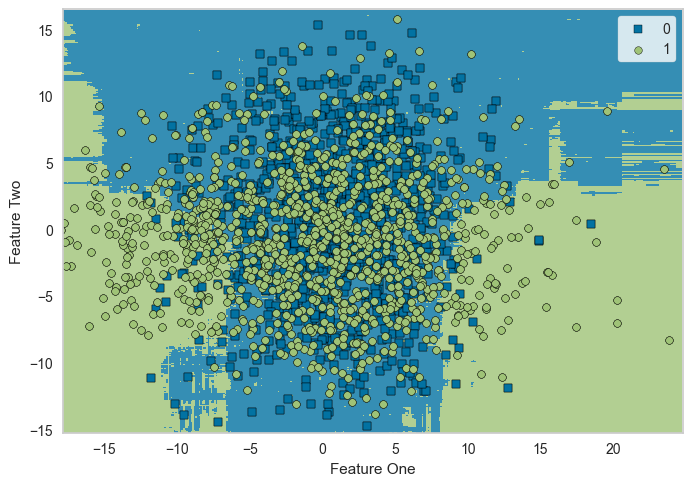

In [120]:
plot_model(cali_model, plot = 'boundary')

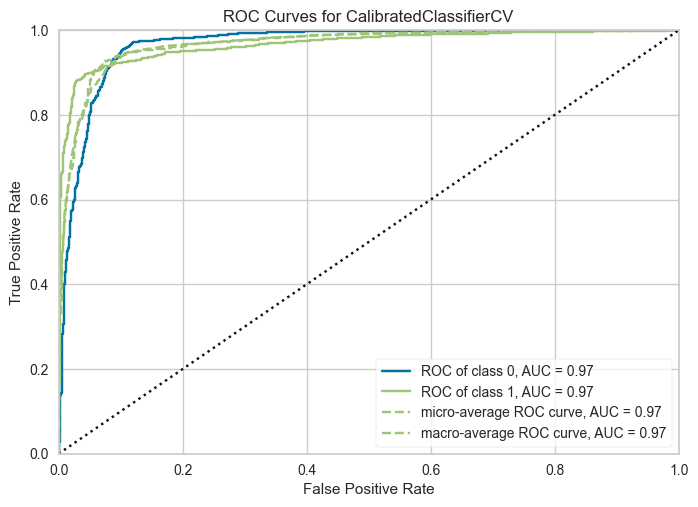

In [119]:
plot_model(cali_model)

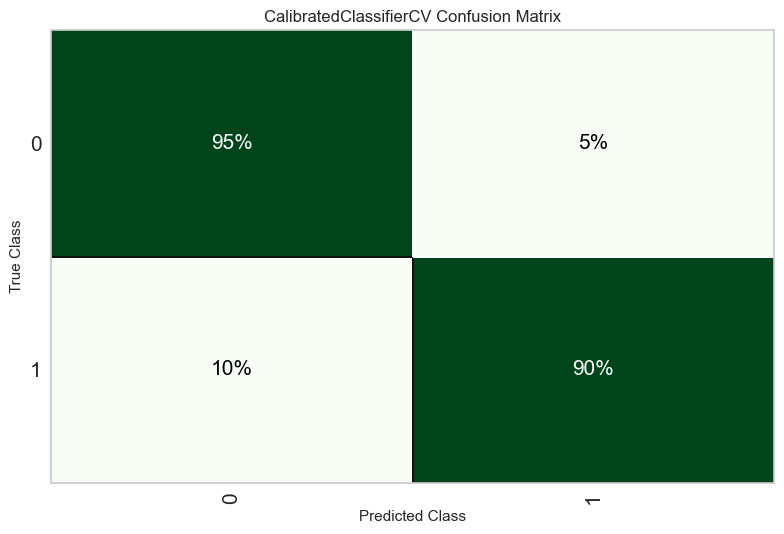

In [124]:
plot_model(cali_model, plot = 'confusion_matrix', plot_kwargs = {'percent' : True})

In [125]:
predict_model(cali_model)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Stacking Classifier,0.9254,0.9666,0.8983,0.9498,0.9233,0.8508,0.8521


[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will b

,name,nAcid,nBase,SpMax_A,SpMAD_A,VE1_A,VR1_A,nBr,ATS2m,ATS6m,...,JGI7,JGI8,JGI9,JGI10,SRW09,TSRW10,WPath,cls,prediction_label,prediction_score
9440,CC1=CC(=C(C(=C1C)S(=O)(=O)NCCCN2CCOCC2)C)C,0,1.0,2.465332,1.229564,3.652364,768.452637,0,6814.648438,4276.907715,...,0.015239,0.012346,0.011111,0.007231,0.000000,57.292469,1302,1,0,0.8340
9441,CC1=C(N2C=CC=NC2=N1)C3=CSC(=N3)NC4=CC=C(C=C4)N...,0,0.0,2.438862,1.294084,4.086513,247.596832,1,7488.730469,5033.080566,...,0.014799,0.009747,0.006720,0.006224,7.525640,76.968193,2500001643,1,1,0.9598
9442,CC1=[N+](C2=C(N1C)C=C(C=C2)Cl)CC3=CC=CC=C3.[I-],1,1.0,2.438862,1.294084,4.086513,247.596832,0,5442.681641,3958.768311,...,0.013423,0.014577,0.010000,0.012346,7.195187,68.207512,1900000680,1,1,0.9727
9443,C1CC(OC1)CNS(=O)(=O)C2=CC=C(C=C2)C3=CC=C(C=C3)...,0,0.0,2.409595,1.293957,4.871051,355.804138,0,10558.621094,8424.211914,...,0.009292,0.006725,0.011603,0.009004,6.951772,83.161232,3588,1,1,0.7553
9444,CC1=CC=CN2C1=NC(=C2)C3=CC4=CC=CC=C4OC3=O,0,0.0,2.482653,1.331947,4.223250,130.264526,0,5809.644043,3757.420898,...,0.014760,0.010478,0.004923,0.005679,6.861712,69.501961,893,1,0,0.8448
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11795,CC1=NN=C(O1)SCC(=O)NC2=CC3=C(C=C2)OCO3,0,0.0,2.370723,1.301287,3.607111,247.863861,0,6316.258301,3759.669434,...,0.007815,0.008781,0.007604,0.005643,7.247793,68.846703,940,0,0,0.9619
11796,C1CC(CN(C1)S(=O)(=O)C2=CC=CC=C2)C(=O)NC3=CC=C(...,0,0.0,2.432201,1.323149,4.267554,551.324890,0,9136.021484,7033.656250,...,0.013889,0.011329,0.006296,0.003958,0.000000,65.778412,2792,0,0,0.9491
11797,CC1=C(C=C(C=C1)NC(=O)CN2C(=O)C3=CC=CC=C3C(=N2)C)F,0,0.0,2.443993,1.275908,3.878948,329.857819,0,6326.751465,4449.249512,...,0.012626,0.012886,0.009079,0.007972,0.000000,58.703388,1425,0,1,0.5794
11798,CCCC1=NC2=NC=NN2C(=C1)N3CCCC(C3)C(=O)NC4=C(C=C...,0,0.0,2.468043,1.314685,4.425002,434.618866,0,8279.666016,8778.245117,...,0.010915,0.010338,0.007533,0.006604,6.605298,80.516701,2754,0,0,0.9720


In [126]:
predict_model(stack_tuned_models)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Stacking Classifier,0.9305,0.9707,0.8958,0.9627,0.9280,0.8610,0.8631


,name,nAcid,nBase,SpMax_A,SpMAD_A,VE1_A,VR1_A,nBr,ATS2m,ATS6m,...,JGI7,JGI8,JGI9,JGI10,SRW09,TSRW10,WPath,cls,prediction_label,prediction_score
9440,CC1=CC(=C(C(=C1C)S(=O)(=O)NCCCN2CCOCC2)C)C,0,1.0,2.465332,1.229564,3.652364,768.452637,0,6814.648438,4276.907715,...,0.015239,0.012346,0.011111,0.007231,0.000000,57.292469,1302,1,0,0.9749
9441,CC1=C(N2C=CC=NC2=N1)C3=CSC(=N3)NC4=CC=C(C=C4)N...,0,0.0,2.438862,1.294084,4.086513,247.596832,1,7488.730469,5033.080566,...,0.014799,0.009747,0.006720,0.006224,7.525640,76.968193,2500001643,1,1,0.9901
9442,CC1=[N+](C2=C(N1C)C=C(C=C2)Cl)CC3=CC=CC=C3.[I-],1,1.0,2.438862,1.294084,4.086513,247.596832,0,5442.681641,3958.768311,...,0.013423,0.014577,0.010000,0.012346,7.195187,68.207512,1900000680,1,1,0.9983
9443,C1CC(OC1)CNS(=O)(=O)C2=CC=C(C=C2)C3=CC=C(C=C3)...,0,0.0,2.409595,1.293957,4.871051,355.804138,0,10558.621094,8424.211914,...,0.009292,0.006725,0.011603,0.009004,6.951772,83.161232,3588,1,1,0.9551
9444,CC1=CC=CN2C1=NC(=C2)C3=CC4=CC=CC=C4OC3=O,0,0.0,2.482653,1.331947,4.223250,130.264526,0,5809.644043,3757.420898,...,0.014760,0.010478,0.004923,0.005679,6.861712,69.501961,893,1,0,0.8794
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11795,CC1=NN=C(O1)SCC(=O)NC2=CC3=C(C=C2)OCO3,0,0.0,2.370723,1.301287,3.607111,247.863861,0,6316.258301,3759.669434,...,0.007815,0.008781,0.007604,0.005643,7.247793,68.846703,940,0,0,0.9764
11796,C1CC(CN(C1)S(=O)(=O)C2=CC=CC=C2)C(=O)NC3=CC=C(...,0,0.0,2.432201,1.323149,4.267554,551.324890,0,9136.021484,7033.656250,...,0.013889,0.011329,0.006296,0.003958,0.000000,65.778412,2792,0,0,0.9218
11797,CC1=C(C=C(C=C1)NC(=O)CN2C(=O)C3=CC=CC=C3C(=N2)C)F,0,0.0,2.443993,1.275908,3.878948,329.857819,0,6326.751465,4449.249512,...,0.012626,0.012886,0.009079,0.007972,0.000000,58.703388,1425,0,1,0.5374
11798,CCCC1=NC2=NC=NN2C(=C1)N3CCCC(C3)C(=O)NC4=C(C=C...,0,0.0,2.468043,1.314685,4.425002,434.618866,0,8279.666016,8778.245117,...,0.010915,0.010338,0.007533,0.006604,6.605298,80.516701,2754,0,0,0.9982


In [127]:
predict_model(tune_stacked_model)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Stacking Classifier,0.9242,0.9685,0.8831,0.9621,0.9209,0.8483,0.8512


[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9


,name,nAcid,nBase,SpMax_A,SpMAD_A,VE1_A,VR1_A,nBr,ATS2m,ATS6m,...,JGI7,JGI8,JGI9,JGI10,SRW09,TSRW10,WPath,cls,prediction_label,prediction_score
9440,CC1=CC(=C(C(=C1C)S(=O)(=O)NCCCN2CCOCC2)C)C,0,1.0,2.465332,1.229564,3.652364,768.452637,0,6814.648438,4276.907715,...,0.015239,0.012346,0.011111,0.007231,0.000000,57.292469,1302,1,0,0.5423
9441,CC1=C(N2C=CC=NC2=N1)C3=CSC(=N3)NC4=CC=C(C=C4)N...,0,0.0,2.438862,1.294084,4.086513,247.596832,1,7488.730469,5033.080566,...,0.014799,0.009747,0.006720,0.006224,7.525640,76.968193,2500001643,1,1,0.5569
9442,CC1=[N+](C2=C(N1C)C=C(C=C2)Cl)CC3=CC=CC=C3.[I-],1,1.0,2.438862,1.294084,4.086513,247.596832,0,5442.681641,3958.768311,...,0.013423,0.014577,0.010000,0.012346,7.195187,68.207512,1900000680,1,1,0.5599
9443,C1CC(OC1)CNS(=O)(=O)C2=CC=C(C=C2)C3=CC=C(C=C3)...,0,0.0,2.409595,1.293957,4.871051,355.804138,0,10558.621094,8424.211914,...,0.009292,0.006725,0.011603,0.009004,6.951772,83.161232,3588,1,1,0.5382
9444,CC1=CC=CN2C1=NC(=C2)C3=CC4=CC=CC=C4OC3=O,0,0.0,2.482653,1.331947,4.223250,130.264526,0,5809.644043,3757.420898,...,0.014760,0.010478,0.004923,0.005679,6.861712,69.501961,893,1,0,0.5468
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11795,CC1=NN=C(O1)SCC(=O)NC2=CC3=C(C=C2)OCO3,0,0.0,2.370723,1.301287,3.607111,247.863861,0,6316.258301,3759.669434,...,0.007815,0.008781,0.007604,0.005643,7.247793,68.846703,940,0,0,0.5663
11796,C1CC(CN(C1)S(=O)(=O)C2=CC=CC=C2)C(=O)NC3=CC=C(...,0,0.0,2.432201,1.323149,4.267554,551.324890,0,9136.021484,7033.656250,...,0.013889,0.011329,0.006296,0.003958,0.000000,65.778412,2792,0,0,0.5632
11797,CC1=C(C=C(C=C1)NC(=O)CN2C(=O)C3=CC=CC=C3C(=N2)C)F,0,0.0,2.443993,1.275908,3.878948,329.857819,0,6326.751465,4449.249512,...,0.012626,0.012886,0.009079,0.007972,0.000000,58.703388,1425,0,0,0.5249
11798,CCCC1=NC2=NC=NN2C(=C1)N3CCCC(C3)C(=O)NC4=C(C=C...,0,0.0,2.468043,1.314685,4.425002,434.618866,0,8279.666016,8778.245117,...,0.010915,0.010338,0.007533,0.006604,6.605298,80.516701,2754,0,0,0.5724


In [128]:
predict_model(blend_hard)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Voting Classifier,0.9174,0.9174,0.8958,0.9362,0.9155,0.8347,0.8355


,name,nAcid,nBase,SpMax_A,SpMAD_A,VE1_A,VR1_A,nBr,ATS2m,ATS6m,...,JGI6,JGI7,JGI8,JGI9,JGI10,SRW09,TSRW10,WPath,cls,prediction_label
9440,CC1=CC(=C(C(=C1C)S(=O)(=O)NCCCN2CCOCC2)C)C,0,1.0,2.465332,1.229564,3.652364,768.452637,0,6814.648438,4276.907715,...,0.021513,0.015239,0.012346,0.011111,0.007231,0.000000,57.292469,1302,1,0
9441,CC1=C(N2C=CC=NC2=N1)C3=CSC(=N3)NC4=CC=C(C=C4)N...,0,0.0,2.438862,1.294084,4.086513,247.596832,1,7488.730469,5033.080566,...,0.017259,0.014799,0.009747,0.006720,0.006224,7.525640,76.968193,2500001643,1,1
9442,CC1=[N+](C2=C(N1C)C=C(C=C2)Cl)CC3=CC=CC=C3.[I-],1,1.0,2.438862,1.294084,4.086513,247.596832,0,5442.681641,3958.768311,...,0.012336,0.013423,0.014577,0.010000,0.012346,7.195187,68.207512,1900000680,1,1
9443,C1CC(OC1)CNS(=O)(=O)C2=CC=C(C=C2)C3=CC=C(C=C3)...,0,0.0,2.409595,1.293957,4.871051,355.804138,0,10558.621094,8424.211914,...,0.024084,0.009292,0.006725,0.011603,0.009004,6.951772,83.161232,3588,1,1
9444,CC1=CC=CN2C1=NC(=C2)C3=CC4=CC=CC=C4OC3=O,0,0.0,2.482653,1.331947,4.223250,130.264526,0,5809.644043,3757.420898,...,0.014768,0.014760,0.010478,0.004923,0.005679,6.861712,69.501961,893,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11795,CC1=NN=C(O1)SCC(=O)NC2=CC3=C(C=C2)OCO3,0,0.0,2.370723,1.301287,3.607111,247.863861,0,6316.258301,3759.669434,...,0.023580,0.007815,0.008781,0.007604,0.005643,7.247793,68.846703,940,0,0
11796,C1CC(CN(C1)S(=O)(=O)C2=CC=CC=C2)C(=O)NC3=CC=C(...,0,0.0,2.432201,1.323149,4.267554,551.324890,0,9136.021484,7033.656250,...,0.014950,0.013889,0.011329,0.006296,0.003958,0.000000,65.778412,2792,0,0
11797,CC1=C(C=C(C=C1)NC(=O)CN2C(=O)C3=CC=CC=C3C(=N2)C)F,0,0.0,2.443993,1.275908,3.878948,329.857819,0,6326.751465,4449.249512,...,0.020231,0.012626,0.012886,0.009079,0.007972,0.000000,58.703388,1425,0,1
11798,CCCC1=NC2=NC=NN2C(=C1)N3CCCC(C3)C(=O)NC4=C(C=C...,0,0.0,2.468043,1.314685,4.425002,434.618866,0,8279.666016,8778.245117,...,0.010986,0.010915,0.010338,0.007533,0.006604,6.605298,80.516701,2754,0,0


In [129]:
predict_model(blend_soft)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Voting Classifier,0.9059,0.9676,0.9263,0.8901,0.9078,0.8119,0.8125


,name,nAcid,nBase,SpMax_A,SpMAD_A,VE1_A,VR1_A,nBr,ATS2m,ATS6m,...,JGI7,JGI8,JGI9,JGI10,SRW09,TSRW10,WPath,cls,prediction_label,prediction_score
9440,CC1=CC(=C(C(=C1C)S(=O)(=O)NCCCN2CCOCC2)C)C,0,1.0,2.465332,1.229564,3.652364,768.452637,0,6814.648438,4276.907715,...,0.015239,0.012346,0.011111,0.007231,0.000000,57.292469,1302,1,0,0.8105
9441,CC1=C(N2C=CC=NC2=N1)C3=CSC(=N3)NC4=CC=C(C=C4)N...,0,0.0,2.438862,1.294084,4.086513,247.596832,1,7488.730469,5033.080566,...,0.014799,0.009747,0.006720,0.006224,7.525640,76.968193,2500001643,1,1,0.9782
9442,CC1=[N+](C2=C(N1C)C=C(C=C2)Cl)CC3=CC=CC=C3.[I-],1,1.0,2.438862,1.294084,4.086513,247.596832,0,5442.681641,3958.768311,...,0.013423,0.014577,0.010000,0.012346,7.195187,68.207512,1900000680,1,1,0.9992
9443,C1CC(OC1)CNS(=O)(=O)C2=CC=C(C=C2)C3=CC=C(C=C3)...,0,0.0,2.409595,1.293957,4.871051,355.804138,0,10558.621094,8424.211914,...,0.009292,0.006725,0.011603,0.009004,6.951772,83.161232,3588,1,1,0.9000
9444,CC1=CC=CN2C1=NC(=C2)C3=CC4=CC=CC=C4OC3=O,0,0.0,2.482653,1.331947,4.223250,130.264526,0,5809.644043,3757.420898,...,0.014760,0.010478,0.004923,0.005679,6.861712,69.501961,893,1,0,0.5016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11795,CC1=NN=C(O1)SCC(=O)NC2=CC3=C(C=C2)OCO3,0,0.0,2.370723,1.301287,3.607111,247.863861,0,6316.258301,3759.669434,...,0.007815,0.008781,0.007604,0.005643,7.247793,68.846703,940,0,0,0.7087
11796,C1CC(CN(C1)S(=O)(=O)C2=CC=CC=C2)C(=O)NC3=CC=C(...,0,0.0,2.432201,1.323149,4.267554,551.324890,0,9136.021484,7033.656250,...,0.013889,0.011329,0.006296,0.003958,0.000000,65.778412,2792,0,0,0.6458
11797,CC1=C(C=C(C=C1)NC(=O)CN2C(=O)C3=CC=CC=C3C(=N2)C)F,0,0.0,2.443993,1.275908,3.878948,329.857819,0,6326.751465,4449.249512,...,0.012626,0.012886,0.009079,0.007972,0.000000,58.703388,1425,0,1,0.6818
11798,CCCC1=NC2=NC=NN2C(=C1)N3CCCC(C3)C(=O)NC4=C(C=C...,0,0.0,2.468043,1.314685,4.425002,434.618866,0,8279.666016,8778.245117,...,0.010915,0.010338,0.007533,0.006604,6.605298,80.516701,2754,0,0,0.7327


I think stack tuned model and cali model both are equally good but stack tuned model is better. One is the calibrated version of the other, and both have similar scores and a very good AUC score as well. 

Final Accuaracy Acheived : 93.05%